In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [4]:
train_path = "../data/raw/walmart-recruiting-store-sales-forecasting/train.csv/train.csv"
test_path = "../data/raw/walmart-recruiting-store-sales-forecasting/test.csv/test.csv"
features_path = "../data/raw/walmart-recruiting-store-sales-forecasting/features.csv/features.csv"
stores_path = "../data/raw/walmart-recruiting-store-sales-forecasting/stores.csv"
sample_path = "../data/raw/walmart-recruiting-store-sales-forecasting/sampleSubmission.csv/sampleSubmission.csv"

In [5]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)
features = pd.read_csv(features_path)
stores = pd.read_csv(stores_path)
sample = pd.read_csv(sample_path)

print("train:", train.shape)
print("test:", test.shape)
print("features:", features.shape)
print("stores:", stores.shape)
print("sample:", sample.shape)

train.head()

train: (421570, 5)
test: (115064, 4)
features: (8190, 12)
stores: (45, 3)
sample: (115064, 2)


,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 421570 entries, 0 to 421569
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   Store         421570 non-null  int64  
 1   Dept          421570 non-null  int64  
 2   Date          421570 non-null  object 
 3   Weekly_Sales  421570 non-null  float64
 4   IsHoliday     421570 non-null  bool   
dtypes: bool(1), float64(1), int64(2), object(1)
memory usage: 13.3+ MB


In [7]:
train.describe()

,Store,Dept,Weekly_Sales
count,421570.000000,421570.000000,421570.000000
mean,22.200546,44.260317,15981.258123
std,12.785297,30.492054,22711.183519
min,1.000000,1.000000,-4988.940000
25%,11.000000,18.000000,2079.650000
50%,22.000000,37.000000,7612.030000
75%,33.000000,74.000000,20205.852500
max,45.000000,99.000000,693099.360000


In [8]:
train.isnull().sum()

Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday       0
dtype: int64

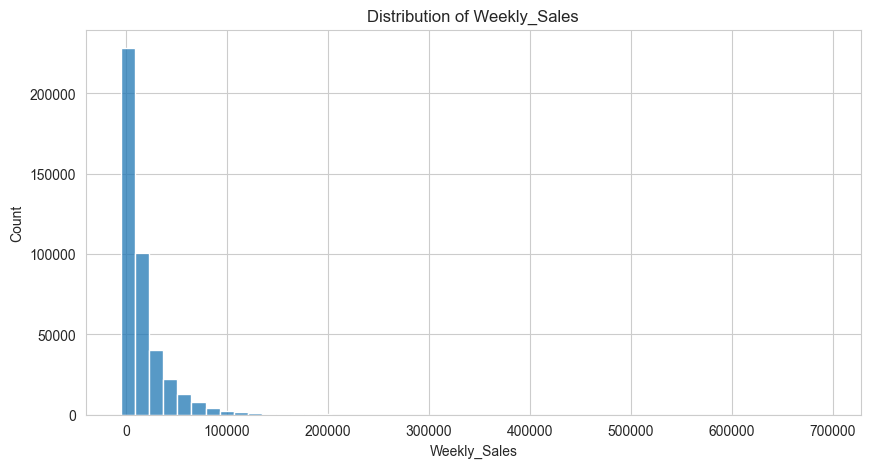

In [9]:
plt.figure(figsize=(10,5))
sns.histplot(train["Weekly_Sales"], bins=50)
plt.title("Distribution of Weekly_Sales")
plt.show()

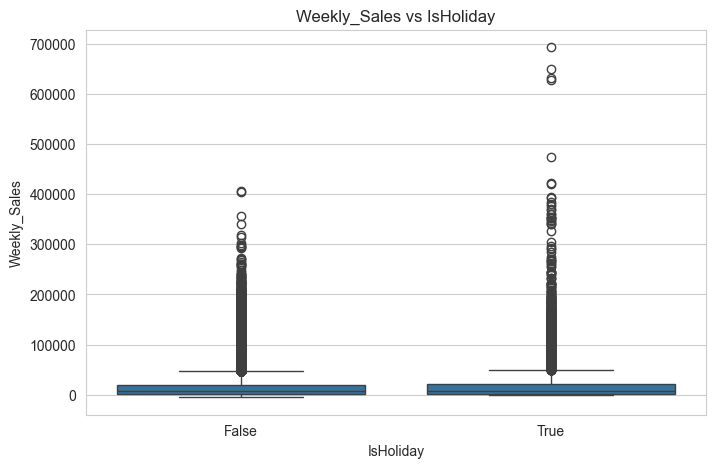

In [10]:
train["IsHoliday"].value_counts()
plt.figure(figsize=(8,5))
sns.boxplot(x="IsHoliday", y="Weekly_Sales", data=train)
plt.title("Weekly_Sales vs IsHoliday")
plt.show()

In [11]:
train["Date"] = pd.to_datetime(train["Date"])
train["year"] = train["Date"].dt.year
train["month"] = train["Date"].dt.month
train["week"] = train["Date"].dt.isocalendar().week.astype(int)
train[["Date", "year", "month", "week"]].head()

,Date,year,month,week
0,2010-02-05,2010,2,5
1,2010-02-12,2010,2,6
2,2010-02-19,2010,2,7
3,2010-02-26,2010,2,8
4,2010-03-05,2010,3,9


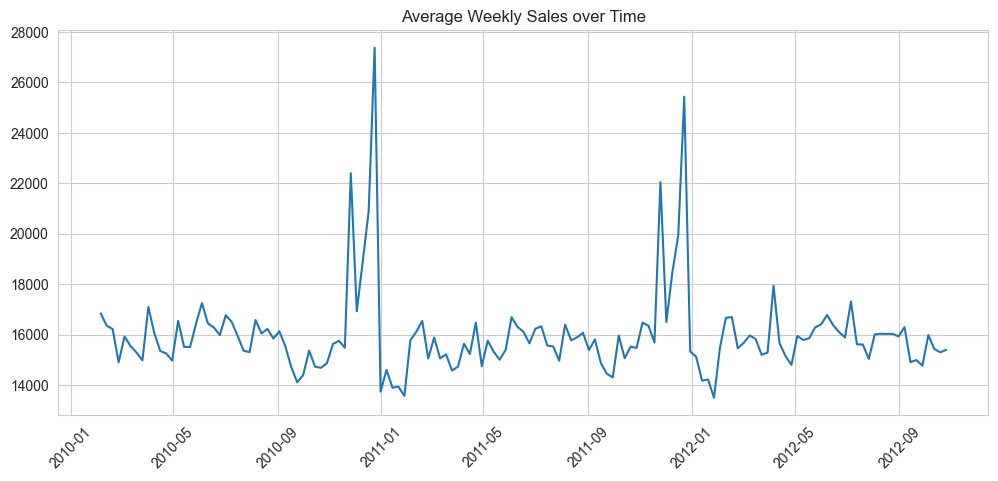

In [12]:
weekly_avg = train.groupby("Date")["Weekly_Sales"].mean().reset_index()

plt.figure(figsize=(12,5))
plt.plot(weekly_avg["Date"], weekly_avg["Weekly_Sales"])
plt.title("Average Weekly Sales over Time")
plt.xticks(rotation=45)
plt.show()

In [15]:
train["Date"] = pd.to_datetime(train["Date"])
features["Date"] = pd.to_datetime(features["Date"])

data = train.merge(features, on=["Store", "Date", "IsHoliday"], how="left")
data = data.merge(stores, on="Store", how="left")

data.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,year,month,week,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,Type,Size
0,1,1,2010-02-05,24924.50,False,2010,2,5,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,A,151315
1,1,1,2010-02-12,46039.49,True,2010,2,6,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,A,151315
2,1,1,2010-02-19,41595.55,False,2010,2,7,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,A,151315
3,1,1,2010-02-26,19403.54,False,2010,2,8,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,A,151315
4,1,1,2010-03-05,21827.90,False,2010,3,9,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,A,151315


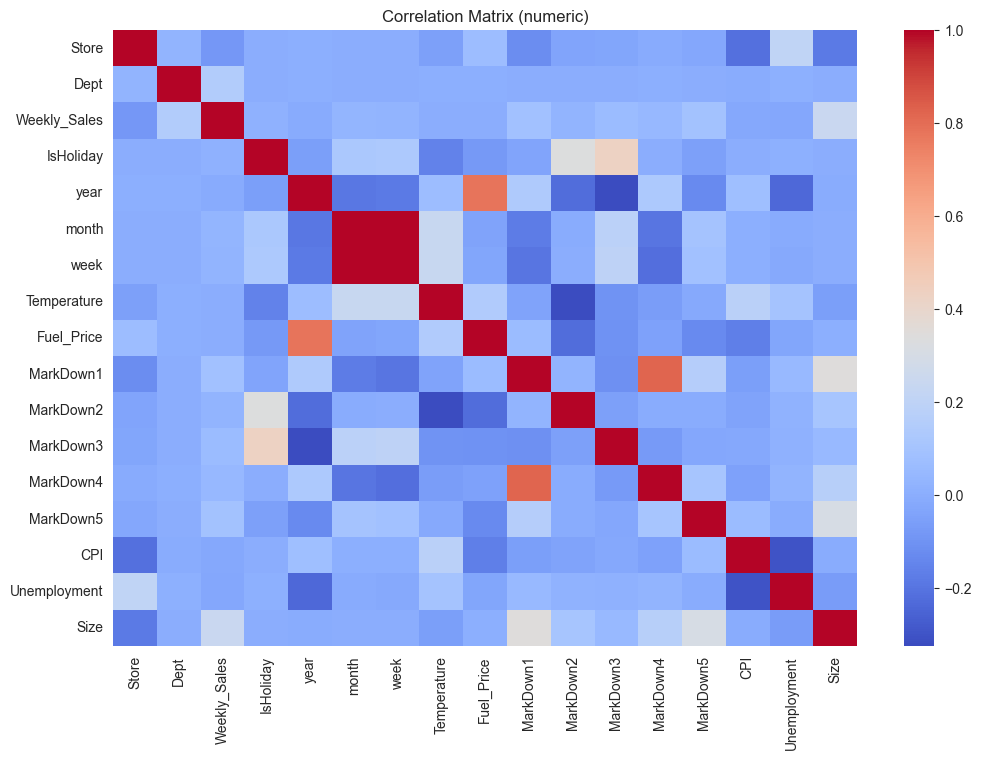

In [17]:
corr = data.corr(numeric_only=True)

plt.figure(figsize=(12,8))
sns.heatmap(corr, cmap="coolwarm")
plt.title("Correlation Matrix (numeric)")
plt.show()

In [19]:
data.isnull().sum().sort_values(ascending=False).head(20)

MarkDown2       310322
MarkDown4       286603
MarkDown3       284479
MarkDown1       270889
MarkDown5       270138
Store                0
Type                 0
Unemployment         0
CPI                  0
Fuel_Price           0
Dept                 0
Temperature          0
week                 0
month                0
year                 0
IsHoliday            0
Weekly_Sales         0
Date                 0
Size                 0
dtype: int64